In [2]:
import numpy as np
import geopandas as gpd
import rasterio
from rasterio.features import rasterize
from rasterio.windows import from_bounds, transform as window_transform
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    precision_recall_curve,
)
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

#### Sample code for making classification performance metrics on raster and ground validation

In [21]:
# =========================
# User inputs (edit these)
# =========================
gpkg_path = "TA64_LA_Wildfires/Closest_to_Sentinel-1_t064a_CA_Perimeters_NIFC_FIRIS_20250203T072944.gpkg"              # polygons in a GeoPackage
gpkg_layer = None                      # e.g. "my_layer" (or None to use default)
eval_bounds_geojson_path = "TA64_LA_Wildfires/Closest_to_Sentinel-1_t064a_CA_Perimeters_NIFC_FIRIS_20250203T072944EvalBounds.geojson"   # has property "mission"

target_raster_paths = [
    "TA64_LA_Wildfires/others/20250109.wprobs.geo.masked.tif",
    "TA64_LA_Wildfires/others/20250109.wprobs.geo.tif",
    # "TA64_LA_Wildfires/others/geo_20250109_mpy_linear.wprobs.tif",
    "TA64_LA_Wildfires/others/geo_20250109_mpy_br500_linear.masked.wprobs.tif",
    "TA64_LA_Wildfires/others/geo_20250109_mpy_br500_linear.wprobs.tif",
    # "TA64_LA_Wildfires/others/geo_20250109_mpy_nn.wprobs.tif",
    # "TA64_LA_Wildfires/others/geoisce_nn_220250109.wprobs.geo.tif",
    "TA64_LA_Wildfires/others/geoisce_linear_20250109.wprobs.masked.geo.tif",
    "TA64_LA_Wildfires/others/geoisce_linear_20250109.wprobs.geo.tif",
    # "TA64_LA_Wildfires/others/geoisce_sinc_20250109.wprobs.geo.tif",
    "TA64_LA_Wildfires/20250109_GSLC_30m_resampled.wprobs.geo.tif"
    # "TA64_LA_Wildfires/others/20250109.wprobs.geo.tif"
]

thresholds = np.round(np.arange(0.50, 0.90 + 1e-9, 0.02), 2)
all_touched = False                    # True if you want "all_touched" rasterization
# save_rasterized_path = f"{os.path.splitext(target_raster_path)[0]}_validation.tif"            # e.g. "labels_on_target_grid.tif" or None

# Optional outputs (GeoTIFFs that will open correctly in QGIS)
save_polygon_raster = True
save_target_clip_path = None     # e.g. "target_clip.tif"

# ---- configurable NoData handling ----
nodata_value = 0               # e.g. 0, 255, -9999, or np.nan
exclude_nodata = True             # if True, nodata pixels are excluded from metrics


# Clip mode:
# "target"   -> full raster
# "gpkg"     -> polygon max extents
# "smallest" -> w
# hichever extent is smaller (raster vs polygons)
clip_mode = "smallest"
gpkg_buffer_pixels = 0   # optional buffer (pixels) for "gpkg" or "smallest"


##### Helpers

In [22]:
def as_binary(arr, threshold=0.5):
    """Convert numeric array to {0,1}. Non-finite -> 0 (masked later)."""
    arr = np.asarray(arr)
    out = np.zeros(arr.shape, dtype=np.uint8)
    out[np.isfinite(arr) & (arr > threshold)] = 1
    return out


In [23]:
def build_valid_mask(arr, nodata_value=None):
    """
    Build a boolean mask of valid pixels.
    nodata_value can be None, np.nan, or a numeric value.
    """
    mask = np.isfinite(arr)

    if nodata_value is None:
        return mask

    if isinstance(nodata_value, float) and np.isnan(nodata_value):
        mask &= ~np.isnan(arr)
    else:
        mask &= (arr != nodata_value)

    return mask

In [24]:
def compute_binary_confusion(y_true_bin, y_pred_score, thresh, valid_mask):
    """Compute confusion matrix and metrics for binary arrays."""
    y_pred_bin = as_binary(y_pred_score, threshold=thresh)
    y_true = y_true_bin[valid_mask].ravel().astype(np.uint8)
    y_pred = y_pred_bin[valid_mask].ravel().astype(np.uint8)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    # Critical Success Index (CSI) / Threat Score
    denom = (tp + fp + fn)
    csi = (tp / denom) if denom else np.nan

    metrics = {
        "total_pixels": y_pred.size,
        "total_valid_pixels":np.sum(valid_mask),
        "thresh":thresh,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "csi":float(csi),  
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "fpr": float(fp / (fp + tn)) if (fp + tn) else np.nan,
        "tpr": float(tp / (tp + fn)) if (tp + fn) else np.nan
        }
    return cm, metrics

In [25]:
def rasterize_gdf_to_grid(gdf, out_shape, transform, all_touched=False):
    shapes = ((geom, 1) for geom in gdf.geometry if geom is not None)
    return rasterize(
        shapes=shapes,
        out_shape=out_shape,
        transform=transform,
        fill=0,
        dtype=np.uint8,
        all_touched=all_touched,
    )

In [26]:
def bounds_area(b):
    minx, miny, maxx, maxy = b
    return max(0.0, maxx - minx) * max(0.0, maxy - miny)


In [27]:
def window_from_bounds(src, bounds, buffer_pixels=0):
    minx, miny, maxx, maxy = bounds
    win = from_bounds(minx, miny, maxx, maxy, transform=src.transform)

    # keep inside raster
    win = win.intersection(rasterio.windows.Window(0, 0, src.width, src.height))

    # optional buffer in pixel space
    if buffer_pixels and buffer_pixels > 0:
        win = rasterio.windows.Window(
            col_off=max(0, win.col_off - buffer_pixels),
            row_off=max(0, win.row_off - buffer_pixels),
            width=min(src.width - max(0, win.col_off - buffer_pixels), win.width + 2 * buffer_pixels),
            height=min(src.height - max(0, win.row_off - buffer_pixels), win.height + 2 * buffer_pixels),
        )

    return win.round_offsets().round_lengths()

In [28]:

def window_from_geom_bounds(src, bounds):
    """Pixel-aligned window from bounds; clipped to raster extent."""
    minx, miny, maxx, maxy = bounds
    win = from_bounds(minx, miny, maxx, maxy, transform=src.transform)
    win = win.intersection(rasterio.windows.Window(0, 0, src.width, src.height))
    return win.round_offsets().round_lengths()


In [29]:
def plot_confusion_matrix(
    cm,
    class_names=("0 (neg)", "1 (pos)"),
    title="Confusion Matrix",
    cmap="Blues",
    normalize=True,
):
    """
    Confusion matrix layout (labels=[0,1]):
    
                    Predicted
                  0           1
    True 0        TN          FP
    True 1        FN          TP
    """
    cm = np.asarray(cm)

    if normalize:
        cm_norm = cm / cm.sum()
    else:
        cm_norm = None

    # Fixed label map for binary CM
    label_map = np.array([
        ["TN", "FP"],
        ["FN", "TP"]
    ])

    fig, ax = plt.subplots(figsize=(5, 5))
    im = ax.imshow(cm, interpolation="nearest", cmap=cmap)

    ax.set_title(title, fontsize=14)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    tick_marks = np.arange(len(class_names))
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)

    ax.set_xticklabels(class_names)
    ax.set_yticklabels(class_names)

    ax.set_xlabel("DPM2 label")
    ax.set_ylabel("Ground validation")

    thresh = cm.max() / 2.0

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if normalize:
                txt = (
                    f"{label_map[i, j]}\n"
                    f"{cm[i, j]:,}\n"
                    f"({cm_norm[i, j]*100:.1f}%)"
                )
            else:
                txt = (
                    f"{label_map[i, j]}\n"
                    f"{cm[i, j]:,}"
                )

            ax.text(
                j, i, txt,
                ha="center",
                va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=11,
                fontweight="bold" if label_map[i, j] in ("TP", "TN") else "normal",
            )

    plt.tight_layout()
    plt.show()

    return fig, ax

In [30]:
def subset_gdf_to_bounds(gdf, bounds):
    """Fast bbox subset using spatial index if available. bounds in gdf CRS."""
    minx, miny, maxx, maxy = bounds
    try:
        sidx = gdf.sindex
        hits = list(sidx.intersection((minx, miny, maxx, maxy)))
        if not hits:
            return gdf.iloc[0:0].copy()
        return gdf.iloc[hits].copy()
    except Exception:
        return gdf.cx[minx:maxx, miny:maxy].copy()

##### OLD CODE

In [31]:
all_results = []   # <-- collect results from all rasters
gdf = gpd.read_file(gpkg_path)
gdf = gdf[gdf.geometry.notnull()].copy()

for target_raster_path in target_raster_paths:
    print("\n======================================")
    print("Processing:", target_raster_path)
    print("======================================")
    # =========================
    # Load vector and align CRS to raster
    # =========================
    
    if gdf.empty:
        raise ValueError("No valid geometries found in the GPKG.")
    if gdf.crs is None:
        raise ValueError("GPKG has no CRS; define it before proceeding.")
    
    with rasterio.open(target_raster_path) as dpm2_src:
        if dpm2_src.crs is None:
            raise ValueError("Target raster has no CRS; cannot align polygons.")
        if gdf.crs != dpm2_src.crs:
            gdf = gdf.to_crs(dpm2_src.crs)
    
    poly_bounds = tuple(gdf.total_bounds)  # (minx, miny, maxx, maxy)
    
    # =========================
    # Read target + decide evaluation grid (FIXED transform/meta handling)
    # =========================
    with rasterio.open(target_raster_path) as dpm2_src:
        raster_bounds = (dpm2_src.bounds.left, dpm2_src.bounds.bottom, dpm2_src.bounds.right, dpm2_src.bounds.top)
    
        if clip_mode == "target":
            chosen_bounds = raster_bounds
            buf_px = 0
            mode_msg = "full raster extent"
    
        elif clip_mode == "gpkg":
            chosen_bounds = poly_bounds
            buf_px = gpkg_buffer_pixels
            mode_msg = "GPKG polygon extent"
    
        elif clip_mode == "smallest":
            if bounds_area(poly_bounds) <= bounds_area(raster_bounds):
                chosen_bounds = poly_bounds
                buf_px = gpkg_buffer_pixels
                mode_msg = "SMALLEST extent = GPKG polygon extent"
            else:
                chosen_bounds = raster_bounds
                buf_px = 0
                mode_msg = "SMALLEST extent = raster extent"
    
        else:
            raise ValueError("clip_mode must be one of: 'target', 'gpkg', 'smallest'.")
    
        win = window_from_bounds(dpm2_src, chosen_bounds, buffer_pixels=buf_px)
    
        # Read ONLY this window
        dpm2_arr_clipped = dpm2_src.read(1, window=win, masked=False)
    
        # ✅ CRITICAL FIX: get the transform for this window from the dataset
        grid_transform = dpm2_src.window_transform(win)
    
        # ✅ CRITICAL FIX: update meta to match the window, so saved rasters won't "scale" in QGIS
        meta_win = dpm2_src.meta.copy()
        meta_win.update(
            height=dpm2_arr_clipped.shape[0],
            width=dpm2_arr_clipped.shape[1],
            transform=grid_transform,
        )
    
    print(f"Clip mode: {clip_mode} ({mode_msg})")
    print("Window used (pixels):", win)
    
    # =========================
    # Rasterize polygons to chosen window grid
    # =========================
    poly_rast = rasterize_gdf_to_grid(
        gdf=gdf,
        out_shape=dpm2_arr_clipped.shape,
        transform=grid_transform,
        all_touched=all_touched,
    )
    
    # =========================
    # Optional: save clipped rasters correctly georeferenced (QGIS will show properly)
    # =========================
    if save_target_clip_path:
        meta_t = meta_win.copy()
        # preserve original dtype for target clip; nodata left as-is (or set if you want)
        with rasterio.open(save_target_clip_path, "w", **meta_t) as dst:
            dst.write(dpm2_arr_clipped, 1)
        print("Saved target clip:", save_target_clip_path)

    if save_polygon_raster:
        save_polygon_raster_path = f"{os.path.splitext(target_raster_path)[0]}_validation.tif"
        meta_p = meta_win.copy()
        meta_p.update(dtype="uint8", count=1, nodata=0, compress="deflate")
        with rasterio.open(save_polygon_raster_path, "w", **meta_p) as dst:
            dst.write(poly_rast.astype(np.uint8), 1)
        print("Saved polygon raster:", save_polygon_raster_path)
    
    # =========================
    # Confusion matrix + metrics
    # =========================
    poly_bin = (poly_rast > 0).astype(np.uint8)
    
    valid_mask = build_valid_mask(dpm2_arr_clipped, nodata_value=nodata_value) if exclude_nodata else np.ones(dpm2_arr_clipped.shape, bool)
    
    # =========================
    # Threshold sweep -> DataFrame
    # =========================
    for thr in thresholds:
        cm, metrics = compute_binary_confusion(poly_bin, dpm2_arr_clipped, thr, valid_mask)
        metrics['raster']= target_raster_path
        print(f"Confusion matrix (rows=true [0,1], cols=pred [0,1]), thresh {metrics['thresh']}:")
        print(cm)
        print(f"TN={metrics['tn']} FP={metrics['fp']} FN={metrics['fn']} TP={metrics['tp']}")
        print(f"Total Pixels       : {metrics['total_pixels']}")
        print(f"Total Valid Pixels : {metrics['total_valid_pixels']}")
        print(f"Accuracy           : {metrics['accuracy']:.6f}")
        print(f"Precision          : {metrics['precision']:.6f}")
        print(f"Recall             : {metrics['recall']:.6f}")
        print(f"F1                 : {metrics['f1']:.6f}")
        print(f"CSI                 : {metrics['csi']:.6f}")
        all_results.append(metrics)
    

df_metrics = pd.DataFrame(all_results)




Processing: TA64_LA_Wildfires/others/20250109.wprobs.geo.masked.tif
Clip mode: smallest (SMALLEST extent = GPKG polygon extent)
Window used (pixels): Window(col_off=1758, row_off=4565, width=2378, height=1476)
Saved polygon raster: TA64_LA_Wildfires/others/20250109.wprobs.geo.masked_validation.tif
Confusion matrix (rows=true [0,1], cols=pred [0,1]), thresh 0.5:
[[1374858 1803514]
 [   8016  108366]]
TN=1374858 FP=1803514 FN=8016 TP=108366
Total Pixels       : 3294754
Total Valid Pixels : 3294754
Accuracy           : 0.450177
Precision          : 0.056680
Recall             : 0.931123
F1                 : 0.106856
CSI                 : 0.056444
Confusion matrix (rows=true [0,1], cols=pred [0,1]), thresh 0.52:
[[1555589 1622783]
 [  10824  105558]]
TN=1555589 FP=1622783 FN=10824 TP=105558
Total Pixels       : 3294754
Total Valid Pixels : 3294754
Accuracy           : 0.504179
Precision          : 0.061075
Recall             : 0.906996
F1                 : 0.114443
CSI                 : 0

##### Main Code

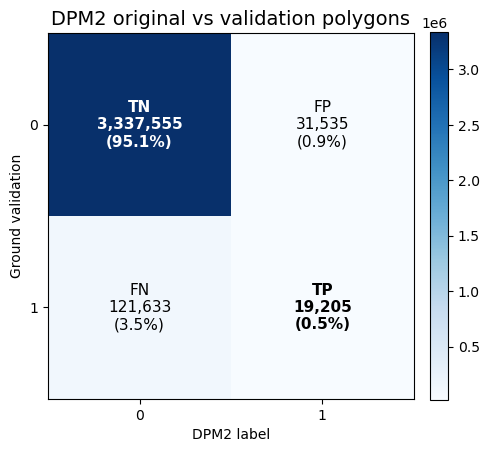

(<Figure size 500x500 with 2 Axes>,
 <Axes: title={'center': 'DPM2 original vs validation polygons'}, xlabel='DPM2 label', ylabel='Ground validation'>)

In [32]:
plot_confusion_matrix(
    cm,
    class_names=("0", "1"),
    title="DPM2 original vs validation polygons",
    normalize=True,
)

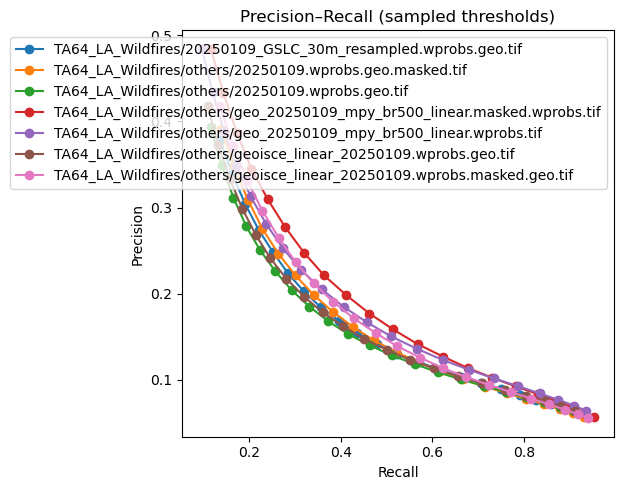

In [33]:
# =========================
# 1) Precision–Recall curve
# =========================
plt.figure(figsize=(6, 5))
for raster, dfg in df_metrics.groupby("raster"):
    plt.plot(dfg["recall"], dfg["precision"], marker="o", label=raster)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall (sampled thresholds)")
plt.legend()
plt.tight_layout()
plt.show()

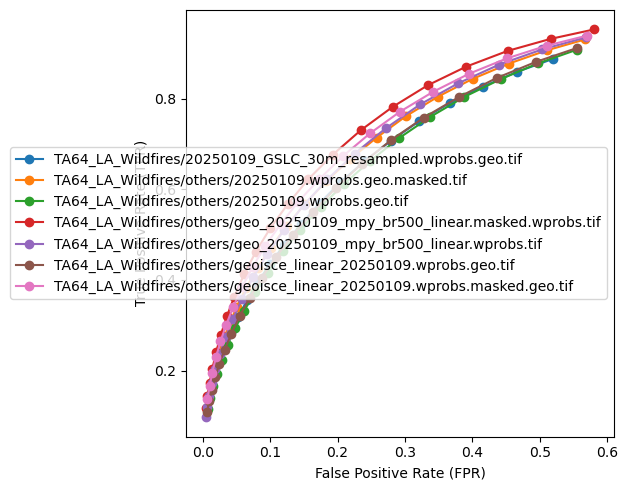

In [34]:
# # =========================
# # 2) ROC curve
# # =========================
# fpr, tpr, roc_thr = roc_curve(y_true_1d, y_score_1d)
# roc_auc = auc(fpr, tpr)

# plt.figure(figsize=(6, 5))
# plt.plot(fpr, tpr)
# plt.plot([0, 1], [0, 1])
# plt.scatter(df_metrics["fpr"], df_metrics["tpr"])
# plt.xlabel("False Positive Rate (FPR)")
# plt.ylabel("True Positive Rate (TPR)")
# plt.title(f"ROC Curve (AUC = {roc_auc:.4f})")
# plt.tight_layout()
# plt.show()


# =========================
# 1) ROC curve
# =========================
plt.figure(figsize=(6, 5))
for raster, dfg in df_metrics.groupby("raster"):
    plt.plot(dfg["fpr"], dfg["tpr"], marker="o", label=raster)

plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
# plt.title(f"ROC Curve (AUC = {roc_auc:.4f})")
plt.legend()
plt.tight_layout()
plt.show()

In [35]:
# # BEST F1
# pd.set_option('display.max_rows', None)

# df_metrics=df_metrics.sort_values("f1", ascending=False).groupby("raster").head
# print(df_metrics)

with pd.option_context("display.max_rows", None):
    display(df_metrics.sort_values("f1", ascending=False))

,total_pixels,total_valid_pixels,thresh,tn,fp,fn,tp,accuracy,precision,recall,csi,f1,fpr,tpr,raster
56,3294639,3294639,0.78,3065211,113001,79231,37196,0.941653,0.247648,0.319479,0.162125,0.279015,0.035555,0.319479,TA64_LA_Wildfires/others/geo_20250109_mpy_br50...
57,3294639,3294639,0.80,3093687,84525,84007,32420,0.948847,0.277224,0.278458,0.161332,0.277840,0.026595,0.278458,TA64_LA_Wildfires/others/geo_20250109_mpy_br50...
55,3294639,3294639,0.76,3029176,149036,74110,42317,0.932270,0.221146,0.363464,0.159408,0.274982,0.046893,0.363464,TA64_LA_Wildfires/others/geo_20250109_mpy_br50...
58,3294639,3294639,0.82,3115905,62307,88474,27953,0.954234,0.309694,0.240090,0.156394,0.270486,0.019604,0.240090,TA64_LA_Wildfires/others/geo_20250109_mpy_br50...
54,3294639,3294639,0.74,2984019,194193,68434,47993,0.920287,0.198166,0.412215,0.154507,0.267659,0.061101,0.412215,TA64_LA_Wildfires/others/geo_20250109_mpy_br50...
99,3247712,3247712,0.80,3027562,108481,78045,33624,0.942567,0.236614,0.301104,0.152732,0.264992,0.034592,0.301104,TA64_LA_Wildfires/others/geoisce_linear_202501...
100,3247712,3247712,0.82,3054087,81956,82150,29519,0.949470,0.264804,0.264344,0.152454,0.264574,0.026134,0.264344,TA64_LA_Wildfires/others/geoisce_linear_202501...
76,3509084,3509084,0.76,3218236,150116,96594,44138,0.929694,0.227218,0.313632,0.151756,0.263521,0.044567,0.313632,TA64_LA_Wildfires/others/geo_20250109_mpy_br50...
77,3509084,3509084,0.78,3254641,113711,102264,38468,0.938453,0.252781,0.273342,0.151185,0.262660,0.033759,0.273342,TA64_LA_Wildfires/others/geo_20250109_mpy_br50...
98,3247712,3247712,0.78,2994486,141557,73617,38052,0.933746,0.211860,0.340757,0.150269,0.261276,0.045139,0.340757,TA64_LA_Wildfires/others/geoisce_linear_202501...


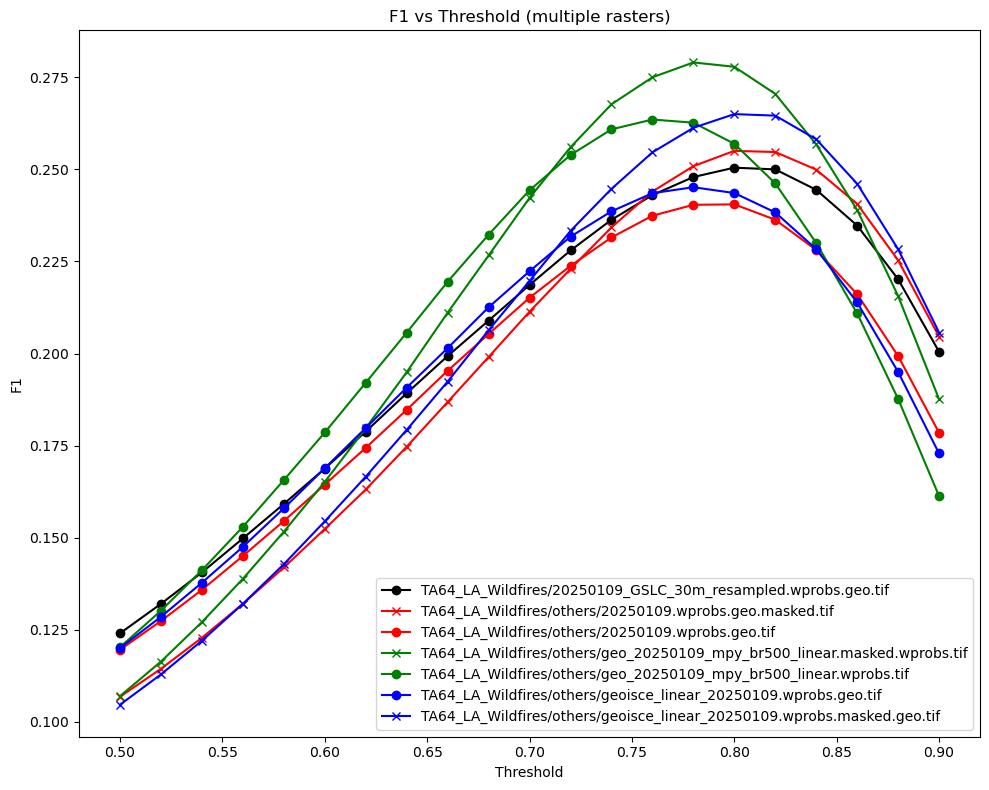

In [40]:
plt.figure(figsize=(10, 8))

# rasters = df_metrics["raster"].unique()
# cmap = plt.cm.viridis  # try: plasma, turbo, inferno, magma
# colors = cmap(np.linspace(0, 1, len(rasters)))
colors = {"geoisce": "blue", "mpy": "green", "GSLC": "black"}

for raster, dfg in  df_metrics.groupby("raster"):
    
    color = next(
        (c for k, c in colors.items() if k in raster),
        "red"
    )
    
    if "mask" in raster:
        
        plt.plot(
        dfg["thresh"],
        dfg["f1"],
        marker="x",
        color=color,
        label=raster
    )

    else:
        plt.plot(
        dfg["thresh"],
        dfg["f1"],
        marker="o",
        color=color,
        label=raster
    )

plt.xlabel("Threshold")
plt.ylabel("F1")
plt.title("F1 vs Threshold (multiple rasters)")
plt.legend()
plt.tight_layout()
plt.show()

In [37]:
# if df_metrics.empty:
#     raise ValueError("No results produced. Check CRS alignment, nodata_value, and min_pixels.")

# for mission, dfg in df_metrics.groupby("mission"):
#     plt.figure(figsize=(10, 8))
#     for raster, dfr in dfg.groupby("raster"):
#         dfr = dfr.sort_values("thresh")
#         plt.plot(dfr["thresh"], dfr["f1"], marker="o", label=os.path.basename(raster))

#     plt.ylim(0, 1)
#     plt.xlabel("Threshold")
#     plt.ylabel("F1")
#     plt.title(f"F1 vs Threshold — {mission}")
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

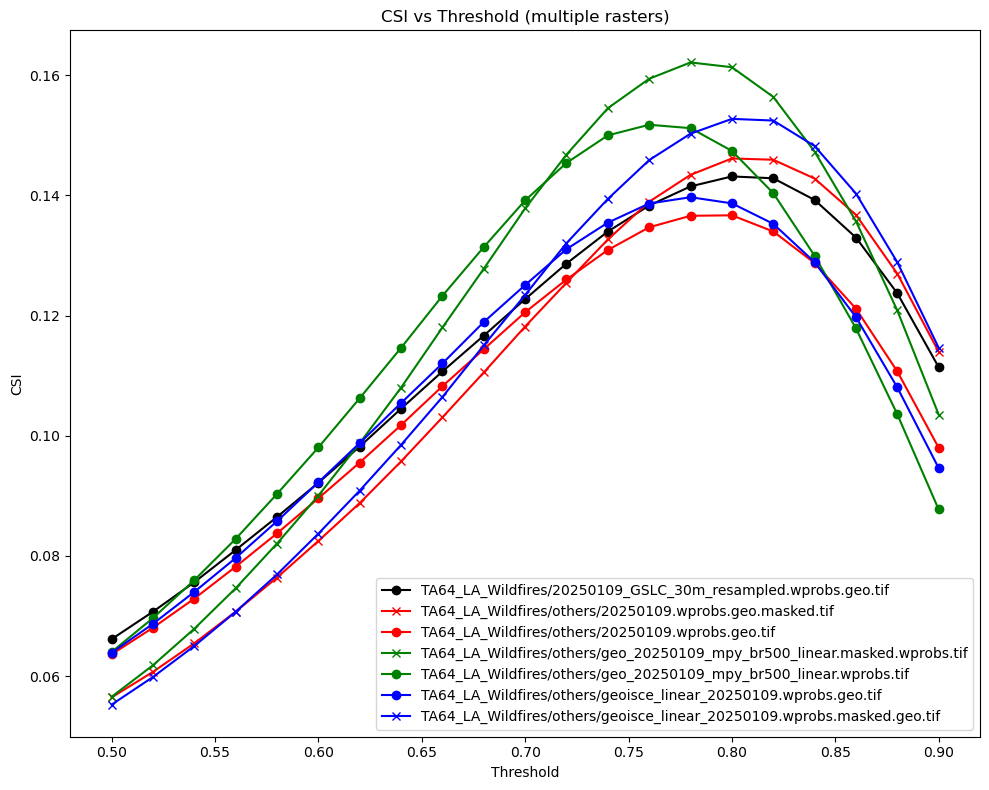

In [41]:
plt.figure(figsize=(10, 8))

# rasters = df_metrics["raster"].unique()
# cmap = plt.cm.viridis  # try: plasma, turbo, inferno, magma
# colors = cmap(np.linspace(0, 1, len(rasters)))
colors = {"geoisce": "blue", "mpy": "green", "GSLC": "black"}

for raster, dfg in  df_metrics.groupby("raster"):
    
    color = next(
        (c for k, c in colors.items() if k in raster),
        "red"
    )
    
    if "mask" in raster:
        
        plt.plot(
        dfg["thresh"],
        dfg["csi"],
        marker="x",
        color=color,
        label=raster
    )

    else:
        plt.plot(
        dfg["thresh"],
        dfg["csi"],
        marker="o",
        color=color,
        label=raster
    )

plt.xlabel("Threshold")
plt.ylabel("CSI")
plt.title("CSI vs Threshold (multiple rasters)")
plt.legend()
plt.tight_layout()
plt.show()